In [14]:
#import the necessary libraries 
from sklearn.neighbors import KNeighborsClassifier     #KNN
from sklearn.linear_model import LogisticRegression    #Logistic Regression
from sklearn.tree import DecisionTreeClassifier        #Decision Tree
from sklearn.ensemble import RandomForestClassifier    #Random Forest
from sklearn.neural_network import MLPClassifier       #Neural Network
from sklearn.svm import SVC                            #SVM
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import export_graphviz
import matplotlib.pylab as plt
import numpy as np
import pandas as pd

%matplotlib inline

In [15]:
# load the data set
df =  pd.read_csv('DB_Voice_Features.csv')
print(df) #display the data set

               name  MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
0    phon_R01_S01_1      119.992       157.302        74.997         0.00784   
1    phon_R01_S01_2      122.400       148.650       113.819         0.00968   
2    phon_R01_S01_3      116.682       131.111       111.555         0.01050   
3    phon_R01_S01_4      116.676       137.871       111.366         0.00997   
4    phon_R01_S01_5      116.014       141.781       110.655         0.01284   
..              ...          ...           ...           ...             ...   
190  phon_R01_S50_2      174.188       230.978        94.261         0.00459   
191  phon_R01_S50_3      209.516       253.017        89.488         0.00564   
192  phon_R01_S50_4      174.688       240.005        74.287         0.01360   
193  phon_R01_S50_5      198.764       396.961        74.904         0.00740   
194  phon_R01_S50_6      214.289       260.277        77.973         0.00567   

     MDVP:Jitter(Abs)  MDVP:RAP  MDVP:P

In [16]:
# get features and target variable
x = df.drop(columns=["name", "status"])
y =  df["status"]

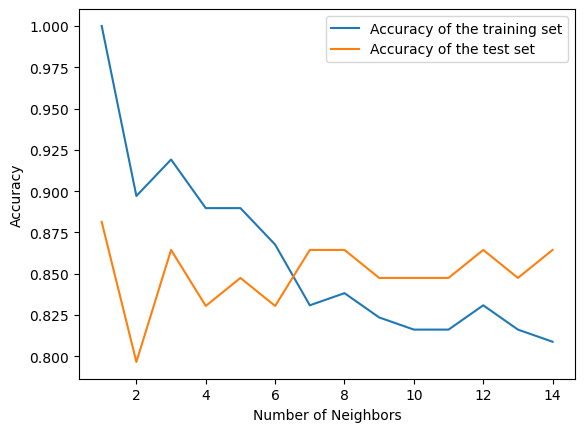

In [24]:
#split the data set into the training and testing set.
#----------KNN Classifier 
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=66)

training_accuracy = []
test_accuracy = []

#try KNN for different k nearest neighbors from 1 to 15
neighbors_setting = range(1,15)

#loop through each value of the number of neighbors
for n_neighbors in neighbors_setting:
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)#initialize KNN classifier with the current number of neighbors
    knn.fit(X_train,y_train)# train the classifier on the training data
    training_accuracy.append(knn.score(X_train, y_train)) #compute and store the accuracy on the training set
    test_accuracy.append(knn.score(X_test, y_test))#compute and store the accuracy on the testing set
 #Plot the training and testing accuracies as a function of the number of neighbors
plt.plot(neighbors_setting,training_accuracy, label='Accuracy of the training set')
plt.plot(neighbors_setting,test_accuracy, label='Accuracy of the test set')
plt.ylabel('Accuracy')
plt.xlabel('Number of Neighbors')
plt.legend()
#by looking at plot, best result accurs when n_neighbors is 15

In [18]:
print("Accuracy of the training set for 6NN: {:3f}".format(training_accuracy[5]))
print("Accuracy of the test set for 6NN: {:3f}".format(test_accuracy[5]))

Accuracy of the training set for 6NN: 0.867647
Accuracy of the test set for 6NN: 0.830508


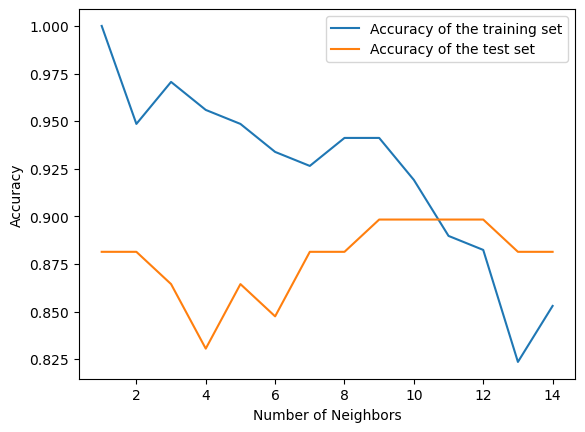

In [19]:
# 1- Scaling X data
scaler = StandardScaler()
X_train_scaled = scaler.fit(X_train).transform(X_train)
X_test_scaled = scaler.fit(X_test).transform(X_test)

training_accuracy = []
test_accuracy = []


#try KNN for different k nearest neighbors from 1 to 15
neighbors_setting = range(1,15)

#loop through each value of the number of neighbors
for n_neighbors in neighbors_setting: 
    knn = KNeighborsClassifier(n_neighbors=n_neighbors) #initialize KNN classifier with the current number of neighbors
    knn.fit(X_train_scaled,y_train)# train the classifier on the training data
    training_accuracy.append(knn.score(X_train_scaled, y_train))#compute and store the accuracy on the training set
    test_accuracy.append(knn.score(X_test_scaled, y_test))
#Plot the training and testing accuracies as a function of the number of neighbors
plt.plot(neighbors_setting,training_accuracy, label='Accuracy of the training set')
plt.plot(neighbors_setting,test_accuracy, label='Accuracy of the test set')
plt.ylabel('Accuracy')
plt.xlabel('Number of Neighbors')
plt.legend()
plt.show()
#by looking at plot, best result accurs when n_neighbors is 15

In [20]:
print("Accuracy of the training set for 12NN: {:3f}".format(training_accuracy[11]))
print("Accuracy of the test set for 12NN: {:3f}".format(test_accuracy[11]))

Accuracy of the training set for 12NN: 0.882353
Accuracy of the test set for 12NN: 0.898305


In [21]:
y_test

7      1
120    1
99     1
98     1
161    1
181    1
147    1
174    0
152    1
18     1
81     1
183    0
17     1
134    1
154    1
96     1
48     0
130    1
148    1
0      1
93     1
106    1
169    0
143    1
115    1
68     1
19     1
8      1
73     1
95     1
54     1
52     0
58     1
189    0
26     1
156    1
13     1
153    1
72     1
109    1
11     1
84     1
37     1
146    1
21     1
53     0
131    1
127    1
138    1
47     0
132    1
5      1
118    1
117    1
33     0
150    1
36     1
111    1
184    0
Name: status, dtype: int64

In [22]:
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

# Make predictions on validation dataset
KNN = KNeighborsClassifier(n_neighbors = 15)
KNN.fit(X_train_scaled, y_train)
predictions = KNN.predict(X_test_scaled)
print(accuracy_score(y_test, predictions))
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

0.8983050847457628
[[ 6  4]
 [ 2 47]]
              precision    recall  f1-score   support

           0       0.75      0.60      0.67        10
           1       0.92      0.96      0.94        49

    accuracy                           0.90        59
   macro avg       0.84      0.78      0.80        59
weighted avg       0.89      0.90      0.89        59



In [23]:
a)Parameter Optimization (80 pts)

Begin by importing the 'pandas' library to access the DataFrame functionality.
Utilize the pd.read_csv() function to import data from the ('DB_Voice_Features.csv') file.
Define variable x as the DataFrame containing all columns of data except for the ('name') and ('status') columns.
Define variable y as the DataFrame containing only the 'status' column.
Implement KNN to evaluate the accuracy on both the training and test sets.
Generate predictions on the validation dataset.


c) Discuss the results obtained (different metrics) (20)

This confusion accuracy indicates that the number on the left represents the total successes,
while the number on the right represents the failures. In this dataset, there are 59 patients
with diabetes and 10 patients in good health. 
The machine detected 47 out of 49 diabetic patients but missed 6 healthy patients.